<a href="https://colab.research.google.com/github/enzoguedescardoso-design/Enzo_Guedes_Cardoso/blob/main/imagem_adicao_de_fundo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install -q "rembg==2.0.55" onnxruntime
print('Instalação concluída!')

Instalação concluída!


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from rembg import remove
from google.colab import files

print('Tudo importado com sucesso!')

Tudo importado com sucesso!


In [15]:
def change_back(background, img):
    """ Uma função que substitui o fundo preto da imagem por outra imagem.
    Aceita dois argumentos: a imagem de fundo (background) e a própria imagem (img).
    A função começa pelo canto superior esquerdo da imagem. Ela procura todos os pixels pretos (com valor 0)
    e os substitui pelos pixels da imagem de fundo. """
    x, y = 0, 0
    background = cv2.resize(background, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_AREA)
    res = np.copy(background)
    place = res[y: y + img.shape[0], x: x + img.shape[1]]
    a = img[..., 3:].repeat(3, axis=2).astype('uint16')
    place[...] = (place.astype('uint16') * (255 - a) // 255) + img[..., :3].astype('uint16') * a // 255
    return res

print('Função change_back definida!')

Função change_back definida!


Envie a imagem cujo fundo será removido:


Saving pessoa_fundo_branco1 to pessoa_fundo_branco1
Largura da imagem: 740
Altura da imagem: 494
Número de canais: 3


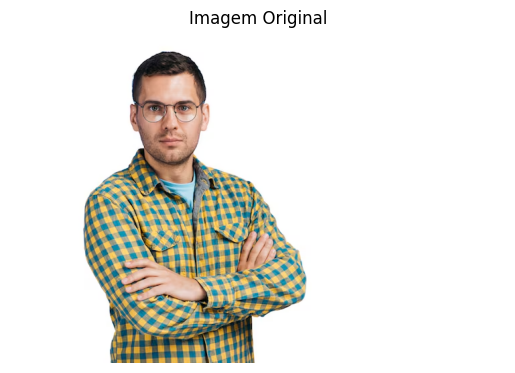

In [16]:
print('Envie a imagem cujo fundo será removido:')
uploaded = files.upload()
nome_sujeito = list(uploaded.keys())[0]

imagem_cv = cv2.imread(nome_sujeito)
height, width, channels = imagem_cv.shape
print('Largura da imagem:', width)
print('Altura da imagem:', height)
print('Número de canais:', channels)

imagem_rgb = cv2.cvtColor(imagem_cv, cv2.COLOR_BGR2RGB)
plt.imshow(imagem_rgb)
plt.title('Imagem Original')
plt.axis('off')
plt.show()

Envie a imagem que será usada como novo fundo:


Saving fundo_de_paisagem_grama_1 to fundo_de_paisagem_grama_1
Largura da imagem: 275
Altura da imagem: 183
Número de canais: 3


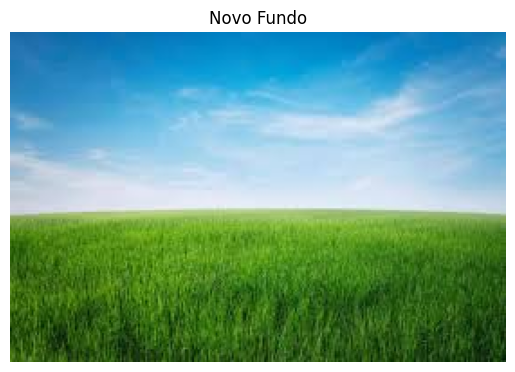

In [17]:
print('Envie a imagem que será usada como novo fundo:')
uploaded2 = files.upload()
nome_fundo = list(uploaded2.keys())[0]

fundo_cv = cv2.imread(nome_fundo)
height2, width2, channels2 = fundo_cv.shape
print('Largura da imagem:', width2)
print('Altura da imagem:', height2)
print('Número de canais:', channels2)

fundo_rgb = cv2.cvtColor(fundo_cv, cv2.COLOR_BGR2RGB)
plt.imshow(fundo_rgb)
plt.title('Novo Fundo')
plt.axis('off')
plt.show()

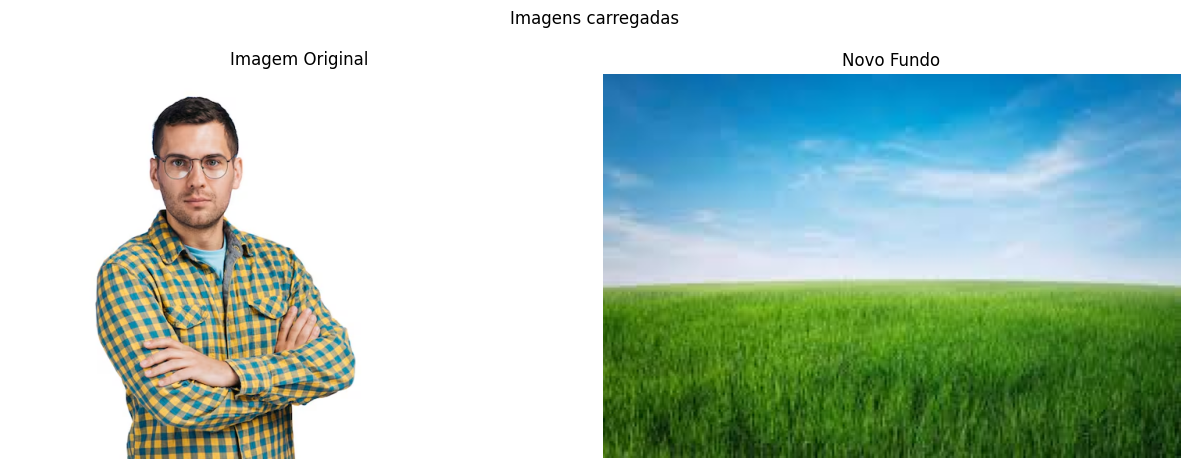

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(imagem_rgb)
axes[0].set_title('Imagem Original')
axes[0].axis('off')

axes[1].imshow(fundo_rgb)
axes[1].set_title('Novo Fundo')
axes[1].axis('off')

plt.suptitle('Imagens carregadas')
plt.tight_layout()
plt.show()

Removendo o fundo... aguarde.
Fundo removido!


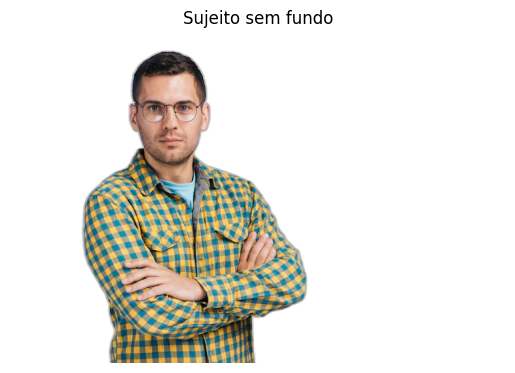

In [19]:
input_image = Image.open(nome_sujeito)

print('Removendo o fundo... aguarde.')
output_image = remove(input_image)
print('Fundo removido!')

plt.imshow(output_image)
plt.title('Sujeito sem fundo')
plt.axis('off')
plt.show()

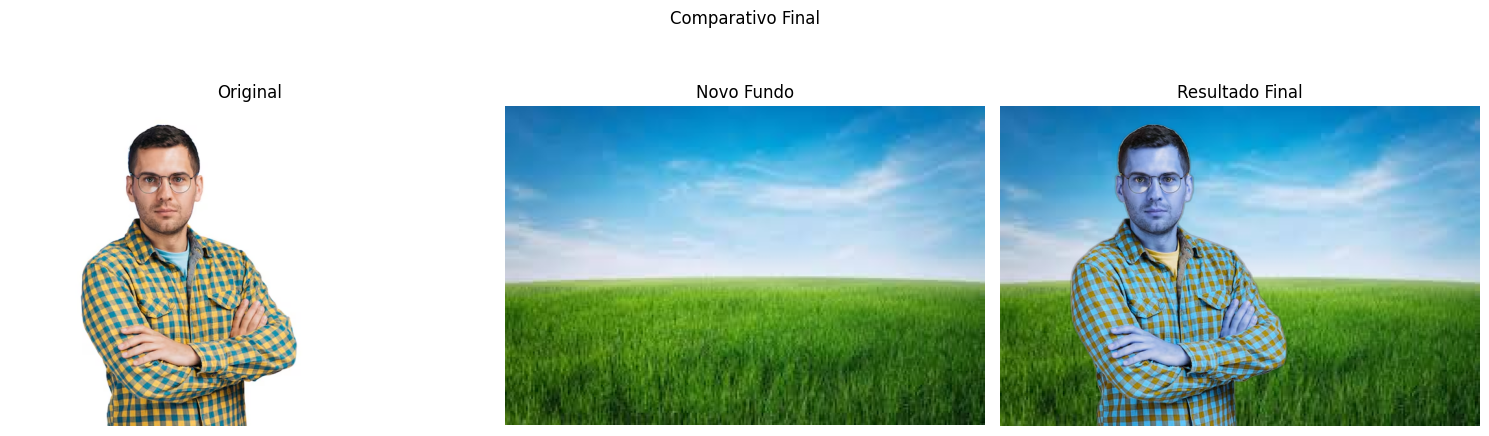

In [20]:
# Converte a imagem sem fundo (PIL RGBA) para numpy array RGBA
img_np = np.array(output_image)

# Chama a função passando o fundo (BGR do cv2) e a imagem RGBA
resultado_bgr = change_back(fundo_cv, img_np)

# Converte BGR -> RGB para exibir corretamente com matplotlib
resultado_rgb = cv2.cvtColor(resultado_bgr, cv2.COLOR_BGR2RGB)

# Exibe o comparativo final
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imagem_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(fundo_rgb)
axes[1].set_title('Novo Fundo')
axes[1].axis('off')

axes[2].imshow(resultado_rgb)
axes[2].set_title('Resultado Final')
axes[2].axis('off')

plt.suptitle('Comparativo Final')
plt.tight_layout()
plt.show()

In [21]:
# Salva em RGB com PIL para evitar inversão de cores
Image.fromarray(resultado_rgb).save('resultado_final.png')
print('Imagem salva como resultado_final.png')
files.download('resultado_final.png')

Imagem salva como resultado_final.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>